In [10]:
# -*- coding: utf-8 -*-
# УЛУЧШЕННЫЙ ЭКСПЕРИМЕНТ
# 200 образцов, 8 временных точек, a2 ∈ [4.0, 8.0], шум 1%

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [11]:
np.random.seed(42)
torch.manual_seed(42)

In [12]:
# 2. ФУНКЦИЯ, ВЫЧИСЛЯЮЩАЯ ТЕОРЕТИЧЕСКУЮ КРИВУЮ ПОЛЗУЧЕСТИ
def creep_strain(t, a0, a1, a2):
    return a0 + a1 * np.exp(-a2 * t)

>>> Улучшенный эксперимент: генерация данных...
    Создано 200 образцов, временных точек: 8.


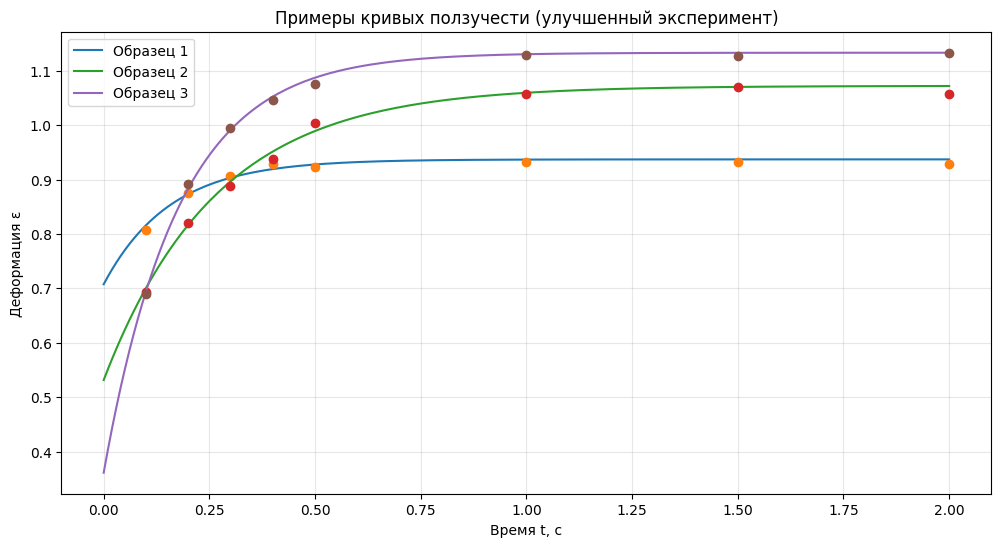

In [13]:
# 3. ГЕНЕРАЦИЯ ДАННЫХ С ФИЗИЧЕСКИМИ ОГРАНИЧЕНИЯМИ

def generate_dataset_improved(n_samples=200, noise_level=0.01):
    t_points = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0])
    X_list, y_list = [], []
    while len(X_list) < n_samples:
        a0 = np.random.uniform(0.6, 1.5)
        a1 = np.random.uniform(-0.8, -0.2)
        a2 = np.random.uniform(2.0, 8.0)
        if a0 + a1 <= 0.05:
            continue
        eps_vals = creep_strain(t_points, a0, a1, a2)
        if np.any(eps_vals <= 0):
            continue
        noise = noise_level * np.random.randn(len(t_points)) * np.abs(eps_vals)
        eps_noisy = eps_vals + noise
        eps_noisy = np.maximum(eps_noisy, 1e-6)
        X_list.append(eps_noisy)
        y_list.append([a0, a1, a2])
    return np.vstack(X_list), np.vstack(y_list), t_points

print(">>> Улучшенный эксперимент: генерация данных...")
t_grid = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0])
X, y, t_grid = generate_dataset_improved(n_samples=200, noise_level=0.01)
print(f"    Создано {X.shape[0]} образцов, временных точек: {len(t_grid)}.")

# Сохранение
df = pd.DataFrame(X, columns=[f"eps_t{t}" for t in t_grid])
df[['a0','a1','a2']] = y
df.to_csv("dataset_improved.csv", index=False)

# Визуализация трёх кривых
t_fine = np.linspace(0, 2, 200)
plt.figure(figsize=(12, 6))
for i in range(3):
    a0, a1, a2 = y[i]
    eps_smooth = creep_strain(t_fine, a0, a1, a2)
    plt.plot(t_fine, eps_smooth, '-', linewidth=1.5, label=f'Образец {i+1}')
    plt.plot(t_grid, X[i], 'o', markersize=6)
plt.xlabel('Время t, с'); plt.ylabel('Деформация ε')
plt.title('Примеры кривых ползучести (улучшенный эксперимент)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [14]:
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ НЕЙРОСЕТИ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = StandardScaler(); scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train); X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train); y_test_scaled = scaler_y.transform(y_test)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [15]:
# 5. АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ (вход теперь 6 нейронов)
class CreepParameterNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3)
        )
    def forward(self, x):
        return self.net(x)

model = CreepParameterNet(len(t_grid))
print("\n>>> Архитектура сети:")
print(model)


>>> Архитектура сети:
CreepParameterNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)



>>> Обучение...
Эпоха 100/800 | Train Loss: 0.047695 | Test Loss: 0.047893
Эпоха 200/800 | Train Loss: 0.032022 | Test Loss: 0.040705
Эпоха 300/800 | Train Loss: 0.033965 | Test Loss: 0.048034
Эпоха 400/800 | Train Loss: 0.028646 | Test Loss: 0.048753
Эпоха 500/800 | Train Loss: 0.025134 | Test Loss: 0.042354
Эпоха 600/800 | Train Loss: 0.027465 | Test Loss: 0.050368
Эпоха 700/800 | Train Loss: 0.029511 | Test Loss: 0.051254
Эпоха 800/800 | Train Loss: 0.025166 | Test Loss: 0.044723


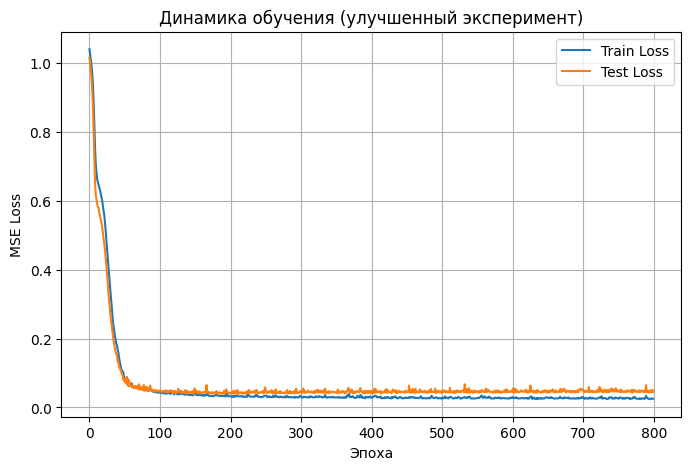

In [16]:
# 6. НАСТРОЙКА ОБУЧЕНИЯ
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 800
train_loss_hist, test_loss_hist = [], []
print("\n>>> Обучение...")
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * batch_X.size(0)
    avg_train = total_train_loss / len(train_loader.dataset)
    train_loss_hist.append(avg_train)
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
        test_loss_hist.append(test_loss)
    if (epoch+1) % 100 == 0:
        print(f"Эпоха {epoch+1:3d}/{epochs} | Train Loss: {avg_train:.6f} | Test Loss: {test_loss:.6f}")

# График обучения
plt.figure(figsize=(8,5))
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(test_loss_hist, label='Test Loss')
plt.xlabel('Эпоха'); plt.ylabel('MSE Loss')
plt.title('Динамика обучения (улучшенный эксперимент)')
plt.legend(); plt.grid(True); plt.show()


>>> РЕЗУЛЬТАТЫ УЛУЧШЕННОГО ЭКСПЕРИМЕНТА:
    Среднеквадратичная ошибка (MSE) : 0.109375
    Коэффициент детерминации R²   : 0.9507
    Средняя абсолютная ошибка (MAE): 0.132107
    a0: R² = 0.9994, MAE = 0.0054
    a1: R² = 0.9679, MAE = 0.0229
    a2: R² = 0.8849, MAE = 0.3680


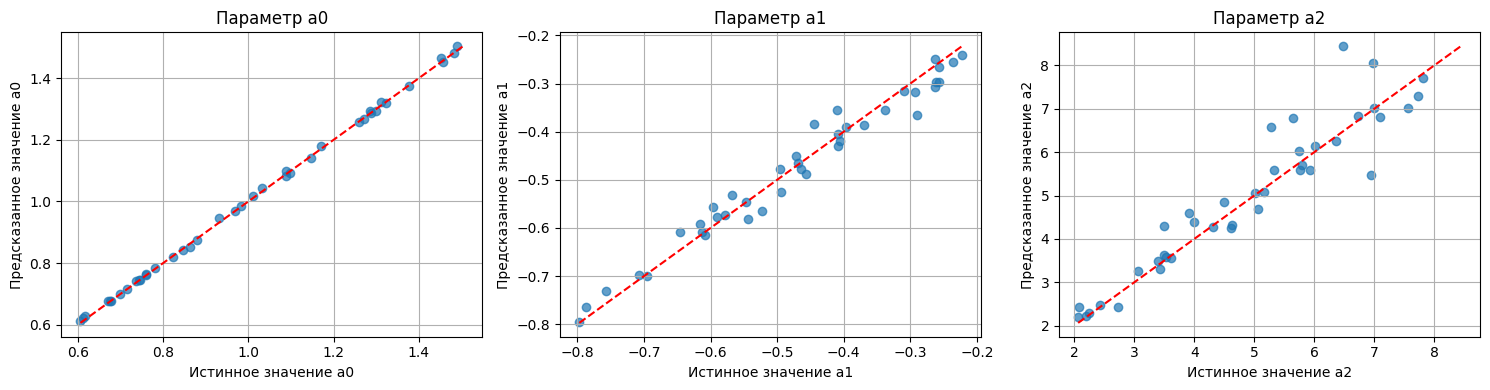

In [17]:
# 7. ТЕСТИРОВАНИЕ И ОЦЕНКА КАЧЕСТВА
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = y_test

mse = np.mean((y_true - y_pred) ** 2)
r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
mae = mean_absolute_error(y_true, y_pred)

print("\n>>> РЕЗУЛЬТАТЫ УЛУЧШЕННОГО ЭКСПЕРИМЕНТА:")
print(f"    Среднеквадратичная ошибка (MSE) : {mse:.6f}")
print(f"    Коэффициент детерминации R²   : {r2:.4f}")
print(f"    Средняя абсолютная ошибка (MAE): {mae:.6f}")

param_names = ['a0', 'a1', 'a2']
for i, name in enumerate(param_names):
    r2_i = r2_score(y_true[:, i], y_pred[:, i])
    mae_i = mean_absolute_error(y_true[:, i], y_pred[:, i])
    print(f"    {name}: R² = {r2_i:.4f}, MAE = {mae_i:.4f}")

# Графики "Истина vs Предсказание"
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(param_names):
    ax = axes[i]
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.7)
    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_xlabel(f'Истинное значение {name}')
    ax.set_ylabel(f'Предсказанное значение {name}')
    ax.set_title(f'Параметр {name}')
    ax.grid(True)
plt.tight_layout()
plt.show()


>>> Улучшенный эксперимент: восстановление кривой для тестового образца
    Истинные параметры:     a0 = 0.7455, a1 = -0.2609, a2 = 5.6386
    Предсказанные параметры: a0 = 0.7460, a1 = -0.2973, a2 = 6.7918


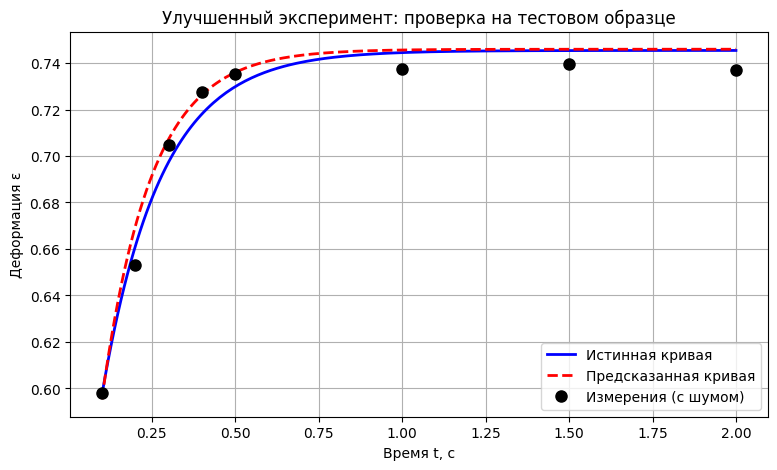

In [26]:
# 8. ВОССТАНОВЛЕНИЕ КРИВОЙ ДЛЯ ТЕСТОВОГО ОБРАЗЦА (улучшенный эксперимент)
print("\n>>> Улучшенный эксперимент: восстановление кривой для тестового образца")

# Выбираем образец из тестовой выборки (не участвовал в обучении)
sample_idx = 1   # можно менять для просмотра разных образцов

# Истинные параметры – из тестовой части датасета
true_params = y_true[sample_idx]
# Предсказанные параметры – то, что выдала нейросеть для этого образца
pred_params = y_pred[sample_idx]
# Входные данные (с шумом), которые подавались сети
eps_noisy = X_test[sample_idx]

print(f"    Истинные параметры:     a0 = {true_params[0]:.4f}, a1 = {true_params[1]:.4f}, a2 = {true_params[2]:.4f}")
print(f"    Предсказанные параметры: a0 = {pred_params[0]:.4f}, a1 = {pred_params[1]:.4f}, a2 = {pred_params[2]:.4f}")

# Строим гладкие кривые на густой сетке
t_fine = np.linspace(0.1, 2.0, 200)
eps_true_curve = creep_strain(t_fine, *true_params)
eps_pred_curve = creep_strain(t_fine, *pred_params)

plt.figure(figsize=(9, 5))
plt.plot(t_fine, eps_true_curve, 'b-', linewidth=2, label='Истинная кривая')
plt.plot(t_fine, eps_pred_curve, 'r--', linewidth=2, label='Предсказанная кривая')
plt.plot(t_grid, eps_noisy, 'ko', markersize=8, label='Измерения (с шумом)')
plt.xlabel('Время t, с')
plt.ylabel('Деформация ε')
plt.title('Улучшенный эксперимент: проверка на тестовом образце')
plt.legend()
plt.grid(True)
plt.show()